<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Mastering_Line_Charts_in_ggplot2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Mastering Line Charts: Visualizing Growth and Trends**

### নোটবুক পরিচিতি (Metadata)
- Aim: এই গাইডের মূল লক্ষ্য হলো Orange ডাটাসেট ব্যবহার করে সময়ের সাথে পরিবর্তনের ধারা (Time-series trend) কীভাবে ggplot2 দিয়ে ফুটিয়ে তোলা যায় তা শেখা।
- Dataset: R-এর বিল্ট-ইন Orange ডাটাসেট (কমলা লেবুর গাছের বয়স বনাম পরিধির তথ্য)।
- Key Skills: Layering (Point + Line), Aesthetics (Color/Alpha), Data Cleaning (Filtering), এবং Factor Reordering.

### কেন লাইন চার্ট ব্যবহার করবেন?
- ১. সময়ের সাথে কোনো পরিবর্তন (Trend) দেখতে।
- ২. বিভিন্ন গ্রুপের (যেমন: বিভিন্ন গাছ) বৃদ্ধির তুলনা করতে।
- ৩. ধারাবাহিক ডেটার (Continuous data) প্যাটার্ন বুঝতে।

### ১. এনভায়রনমেন্ট সেটআপ (Setup)
শুরুতেই প্রয়োজনীয় লাইব্রেরি এবং ডাটাসেট লোড করে নেওয়া যাক।

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# ডাটাসেটটি দেখা
glimpse(Orange)

Rows: 35
Columns: 3
$ Tree          <ord> 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3,…
$ age           <dbl> 118, 484, 664, 1004, 1231, 1372, 1582, 118, 484, 664, 10…
$ circumference <dbl> 30, 58, 87, 115, 120, 142, 145, 33, 69, 111, 156, 172, 2…


In [3]:
# প্রথম ৬টি রো দেখার জন্য
head(Orange)

,Tree,age,circumference
,<ord>,<dbl>,<dbl>
1,1,118,30
2,1,484,58
3,1,664,87
4,1,1004,115
5,1,1231,120
6,1,1372,142


### ২. লাইন চার্টের বিবর্তন (The Evolution of Plot)
একটি প্রফেশনাল গ্রাফ সরাসরি তৈরি হয় না, এটি লেয়ার বাই লেয়ার তৈরি করতে হয়।

#### ধাপ ১: বেসিক স্ক্যাটার প্লট (The Foundation)
শুরুতে আমরা শুধু বিন্দুগুলো দিয়ে ডেটার অবস্থান দেখি।

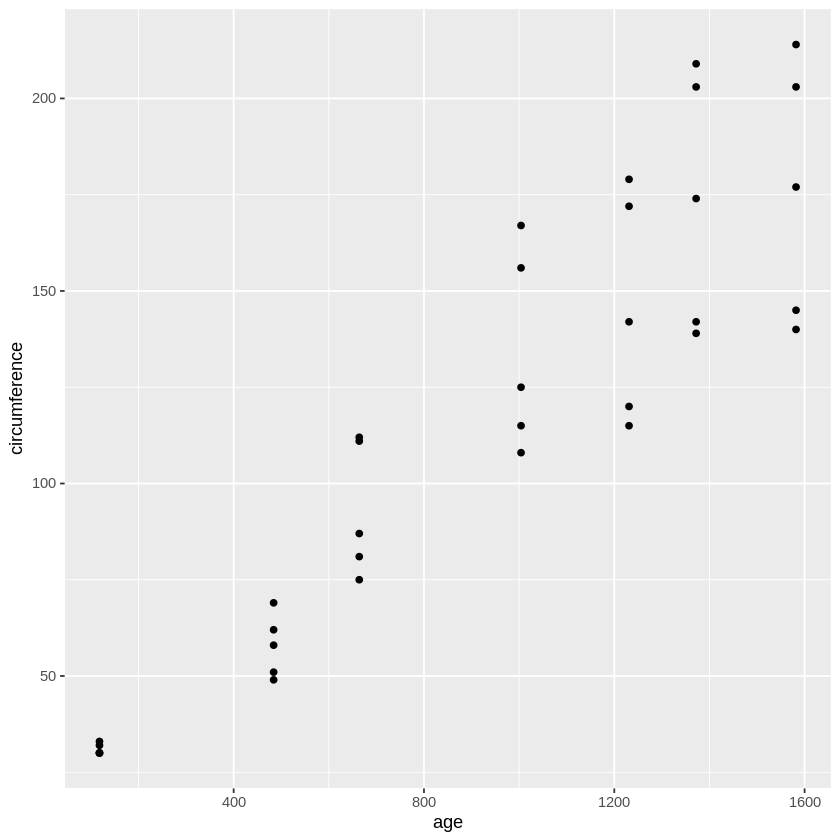

In [4]:
Orange %>%
  ggplot(aes(age, circumference)) +
  geom_point()

#### ধাপ ২ ও ৩: গ্রুপ এবং স্টাইলিং (Color & Customization)
এখন আমরা প্রতিটি গাছকে আলাদা রঙ দিয়ে চিহ্নিত করব এবং বিন্দুগুলোকে আরও রিডাবল করব।

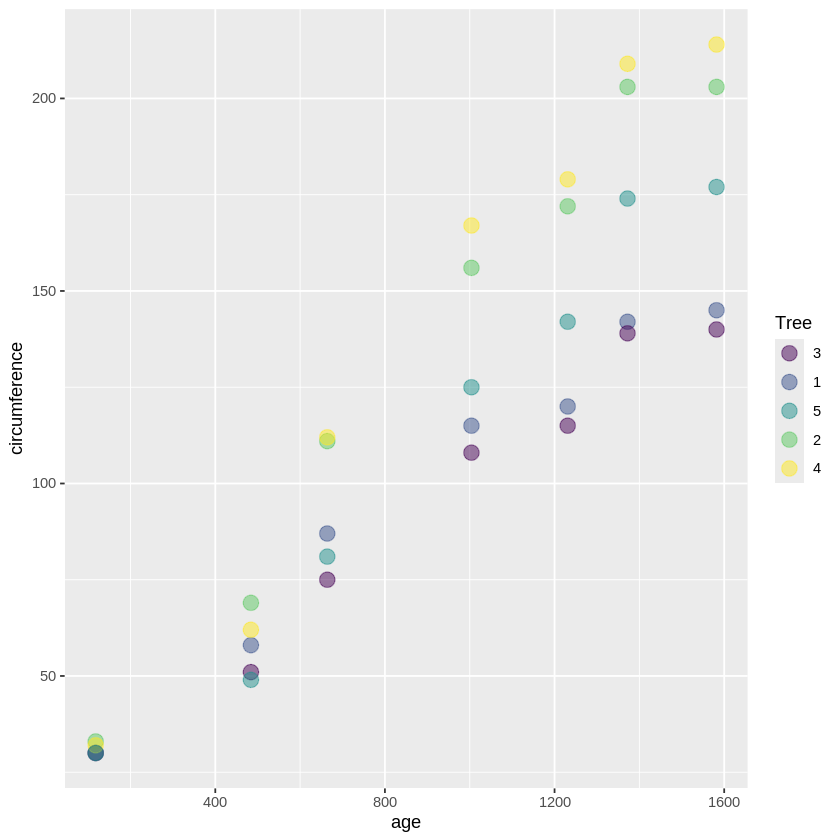

In [5]:
Orange %>%
  ggplot(aes(age, circumference, color = Tree)) +
  geom_point(size = 4, alpha = 0.5) # বড় এবং হালকা স্বচ্ছ বিন্দু

**ব্যাখ্যা:** alpha = 0.5 ব্যবহারের ফলে যদি একটি বিন্দু অন্যটির ওপর পড়ে, তবে দুটিই স্পষ্ট বোঝা যায়।

#### ধাপ ৪: ডটগুলো যুক্ত করা (Adding Lines)
বিন্দুগুলোকে রেখা দিয়ে যুক্ত করলে বৃদ্ধির ধারাটি (Trend) ফুটে ওঠে।

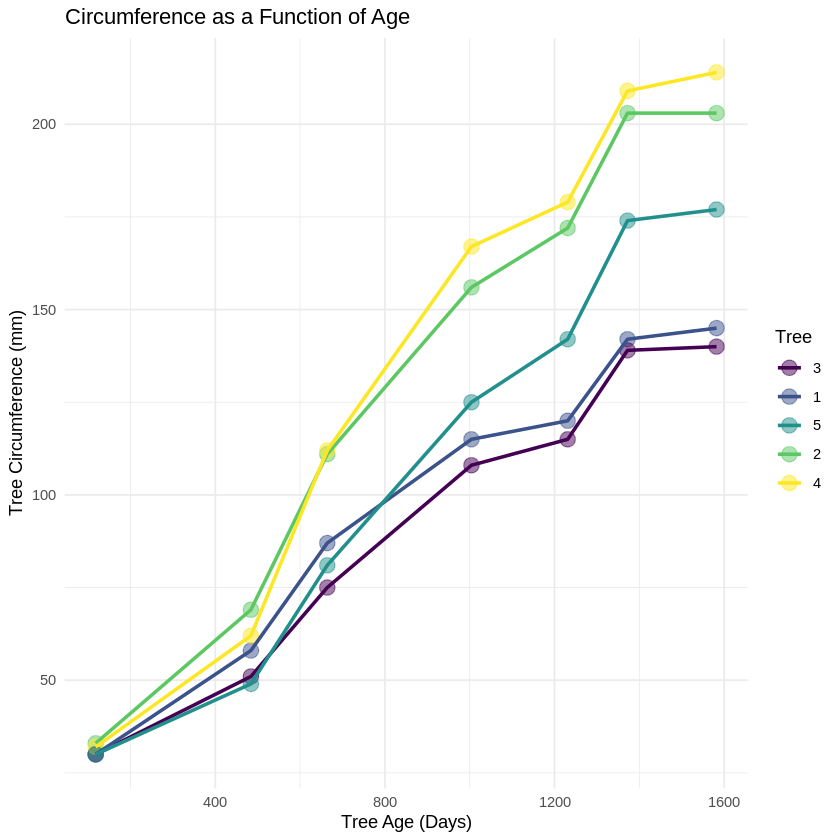

In [6]:
Orange %>%
  ggplot(aes(age, circumference, color = Tree)) +
  geom_point(size = 4, alpha = 0.5) +
  geom_line(linewidth = 1) + # রেখা যোগ করা
  labs(title = "Circumference as a Function of Age",
       x = "Tree Age (Days)",
       y = "Tree Circumference (mm)") +
  theme_minimal()

### ৩. অ্যাডভান্সড ডেটা ম্যানিপুলেশন (Transformation)
কখনও কখনও গ্রাফ তৈরির আগে ডেটাকে গুছিয়ে নিতে হয়।

#### ক) ফ্যাক্টর রি-অর্ডারিং (Reordering Factor Levels)
R-এ ক্যাটাগরিক্যাল ডেটা (Tree 1, 2, 3...) ডিফল্টভাবে সাজানো থাকে। আমরা চাইলে আমাদের পছন্দমতো ক্রম ঠিক করতে পারি।

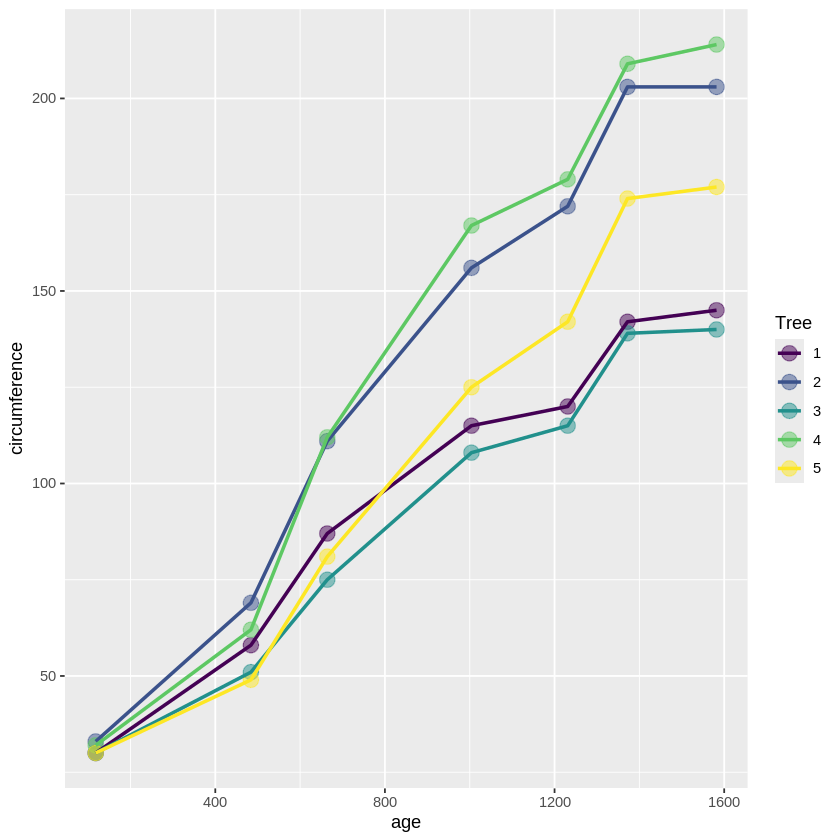

In [7]:
Orange %>%
  mutate(Tree = factor(Tree, levels = c("1", "2", "3", "4", "5"))) %>%
  ggplot(aes(age, circumference, color = Tree)) +
  geom_point(size = 4, alpha = 0.5) +
  geom_line(linewidth = 1)

#### খ) নির্দিষ্ট ডেটা ফিল্টার করা (Filtering)
সব গাছের তথ্য না দেখে যদি শুধু নির্দিষ্ট কিছু গাছের তুলনা করতে চাই:

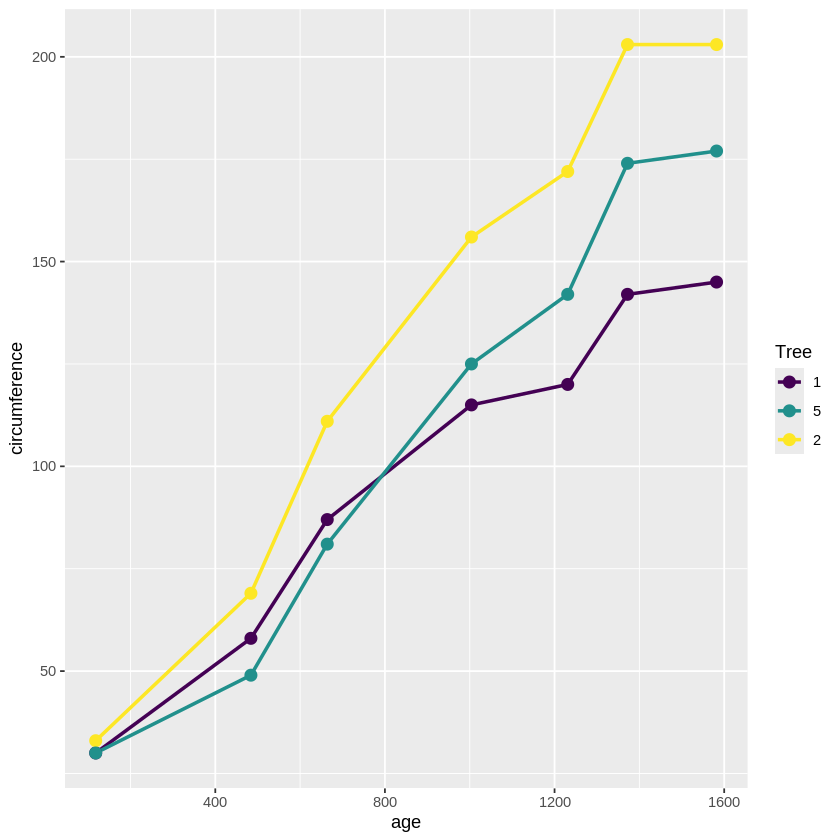

In [8]:
# শুধু গাছ ১, ২ এবং ৫ এর তথ্য দেখা
Orange %>%
  filter(Tree %in% c(1, 2, 5)) %>%
  ggplot(aes(age, circumference, color = Tree)) +
  geom_line(linewidth = 1) +
  geom_point(size = 3)

#### এক নজরে আপনার শেখা টুলকিট (Cheat Sheet):

- geom_point(): ডেটার সঠিক অবস্থান বা বিন্দু দেখায়।
- geom_line(): বিন্দুগুলোকে যুক্ত করে ট্রেন্ড দেখায়।
- color = Tree: প্রতিটি ক্যাটাগরিকে আলাদা রঙ দেয়।
- mutate(factor(...)): ক্যাটাগরিগুলোকে নির্দিষ্ট ক্রমে সাজায়।
- filter(): অপ্রয়োজনীয় ডেটা বাদ দিয়ে ফোকাসড গ্রাফ তৈরি করে।